In [1]:
import pandas as pd
import numpy as np

train = pd.read_csv("train-test.csv")
val = pd.read_csv("validation.csv")
val_template = pd.read_csv("validation-predictions-template.csv")
december = pd.read_csv("december-chart-inputs.csv")

print(train.shape, val.shape, val_template.shape, december.shape)
print(train.dtypes)

(48000, 14) (12000, 13) (12000, 2) (31, 7)
load_id             str
pickup              str
delivery            str
pickup_lat      float64
pickup_lon      float64
delivery_lat    float64
delivery_lon    float64
distance        float64
equipment           str
weight          float64
date                str
market_index    float64
quote_signal    float64
posted_rate     float64
dtype: object


In [2]:
# Converting dates to datetime
train["date"] = pd.to_datetime(train["date"])
val["date"] = pd.to_datetime(val["date"])
december["date"] = pd.to_datetime(december["date"])

# Check missing value patterns before fixing
print("Train missing weight:", train["weight"].isna().sum())
print("Train missing market_index:", train["market_index"].isna().sum())
print("Val missing weight:", val["weight"].isna().sum())
print("Val missing market_index:", val["market_index"].isna().sum())

# Fill missing values with median (document this choice in your report)
weight_median = train["weight"].median()
market_index_median = train["market_index"].median()

for df in [train, val]:
    df["weight"] = df["weight"].fillna(weight_median)
    df["market_index"] = df["market_index"].fillna(market_index_median)

# Time-based features — critical since validation is entirely future data
for df in [train, val, december]:
    df["month"] = df["date"].dt.month
    df["day_of_week"] = df["date"].dt.dayofweek
    df["day_of_year"] = df["date"].dt.dayofyear

# Encode equipment type
train["equipment"] = train["equipment"].astype("category")
val["equipment"] = pd.Categorical(val["equipment"], categories=train["equipment"].cat.categories)
december["equipment"] = pd.Categorical(december["equipment"], categories=train["equipment"].cat.categories)

train["equipment_code"] = train["equipment"].cat.codes
val["equipment_code"] = val["equipment"].cat.codes
december["equipment_code"] = december["equipment"].cat.codes

print("\nDone. Train shape:", train.shape)
print(train[["date", "month", "day_of_week", "day_of_year", "equipment_code"]].head())

Train missing weight: 300
Train missing market_index: 374
Val missing weight: 165
Val missing market_index: 249

Done. Train shape: (48000, 18)
        date  month  day_of_week  day_of_year  equipment_code
0 2025-01-01      1            2            1               0
1 2025-01-01      1            2            1               2
2 2025-01-01      1            2            1               0
3 2025-01-01      1            2            1               0
4 2025-01-01      1            2            1               2


In [3]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# TIME-AWARE SPLIT: hold out the most recent training months as internal validation
# This mimics the real task, since actual validation.csv is entirely future data (Nov-Dec)
cutoff_date = "2025-09-01"

internal_train = train[train["date"] < cutoff_date].copy()
internal_val = train[train["date"] >= cutoff_date].copy()

print("Internal train:", internal_train.shape, "date range:", internal_train["date"].min(), "-", internal_train["date"].max())
print("Internal val:", internal_val.shape, "date range:", internal_val["date"].min(), "-", internal_val["date"].max())

features = ["distance", "weight", "market_index", "quote_signal",
            "month", "day_of_week", "day_of_year", "equipment_code"]

X_train = internal_train[features]
y_train = internal_train["posted_rate"]
X_val = internal_val[features]
y_val = internal_val["posted_rate"]

model = RandomForestRegressor(n_estimators=300, random_state=42, max_depth=12)
model.fit(X_train, y_train)

preds = model.predict(X_val)
mae = mean_absolute_error(y_val, preds)
rmse = np.sqrt(mean_squared_error(y_val, preds))

print(f"\nMAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"Mean posted_rate in validation: {y_val.mean():.2f}")

Internal train: (38477, 18) date range: 2025-01-01 00:00:00 - 2025-08-31 00:00:00
Internal val: (9523, 18) date range: 2025-09-01 00:00:00 - 2025-10-31 00:00:00

MAE: 191.47
RMSE: 683.16
Mean posted_rate in validation: 2392.45


In [4]:
features = ["distance", "weight", "market_index", "quote_signal",
            "month", "day_of_week", "day_of_year", "equipment_code"]

X_train = internal_train[features]
y_train = internal_train["posted_rate"]
X_val = internal_val[features]
y_val = internal_val["posted_rate"]

print("X_train shape:", X_train.shape)
print("Any NaN in X_train:", X_train.isna().sum().sum())
print("Any NaN in X_val:", X_val.isna().sum().sum())

X_train shape: (38477, 8)
Any NaN in X_train: 0
Any NaN in X_val: 0


In [6]:
model = RandomForestRegressor(n_estimators=300, random_state=42, max_depth=12)
model.fit(X_train, y_train)
print("Model trained successfully")

preds = model.predict(X_val)
print("Predictions made, shape:", preds.shape)

mae = mean_absolute_error(y_val, preds)
rmse = np.sqrt(mean_squared_error(y_val, preds))

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"Mean posted_rate in validation: {y_val.mean():.2f}")

Model trained successfully
Predictions made, shape: (9523,)
MAE: 191.47
RMSE: 683.16
Mean posted_rate in validation: 2392.45


In [7]:
# Investigate the biggest errors
internal_val_copy = internal_val.copy()
internal_val_copy["predicted"] = preds
internal_val_copy["error"] = np.abs(internal_val_copy["posted_rate"] - internal_val_copy["predicted"])

worst_errors = internal_val_copy.sort_values("error", ascending=False).head(15)
print(worst_errors[["pickup", "delivery", "distance", "equipment", "weight", "posted_rate", "predicted", "error"]])

             pickup       delivery  distance equipment   weight  posted_rate  \
40171    Montgomery         Fresno    2283.4   Dry Van  32447.0     20361.89   
40096     Baltimore  Oklahoma City    1760.3    Reefer  29521.0     20132.37   
46213      Columbia         Tucson    2023.4   Flatbed  34710.0     17893.17   
43539     Milwaukee    Bakersfield    1893.0   Dry Van  30760.0     17514.11   
47298        Boston    Bakersfield    2979.1    Reefer  30585.0     19110.30   
40322    Montgomery        El Paso    1639.9   Dry Van  38363.0     14949.25   
46516        Toledo    Albuquerque    1684.3    Reefer  31536.0     14784.38   
42149  Grand Rapids        Lubbock    1415.5   Dry Van  35333.0     13026.22   
46366   Bakersfield       Columbia    2251.9   Dry Van  40729.0     14403.14   
44267        Albany    Albuquerque    2492.6   Dry Van  25513.0     14425.42   
43302       Atlanta        Phoenix    2083.1    Reefer  40335.0     13894.55   
43384     Lexington        Lubbock    11

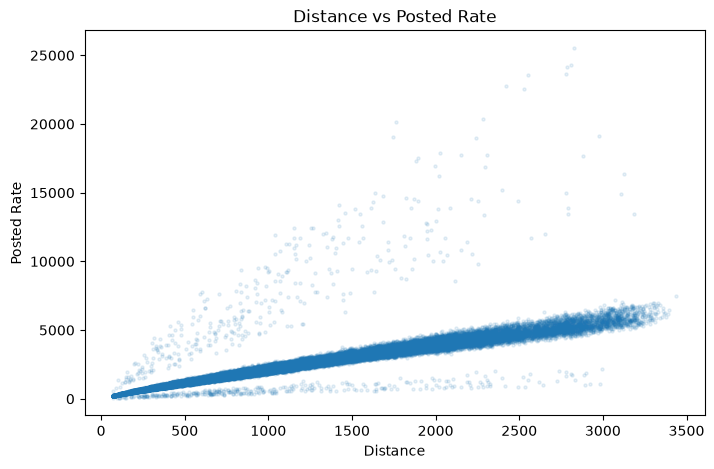

Correlation (distance, posted_rate): 0.9085191518300771

Rate per mile by distance bucket:
distance_bucket
(0, 500]        2.564907
(500, 1000]     2.236443
(1000, 1500]    2.125952
(1500, 2000]    2.044124
(2000, 5000]    1.941750
Name: rate_per_mile, dtype: float64


In [8]:
# Check correlation and relationship shape between distance and rate
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(train["distance"], train["posted_rate"], alpha=0.1, s=5)
plt.xlabel("Distance")
plt.ylabel("Posted Rate")
plt.title("Distance vs Posted Rate")
plt.show()

print("Correlation (distance, posted_rate):", train["distance"].corr(train["posted_rate"]))

# Check rate per mile - does this reveal a clearer pattern?
train["rate_per_mile"] = train["posted_rate"] / train["distance"]
print("\nRate per mile by distance bucket:")
train["distance_bucket"] = pd.cut(train["distance"], bins=[0, 500, 1000, 1500, 2000, 5000])
print(train.groupby("distance_bucket", observed=True)["rate_per_mile"].mean())

In [9]:
# Isolate the high outliers relative to distance
train["expected_rate"] = train["distance"] * 2.2  # rough average rate per mile
train["rate_ratio"] = train["posted_rate"] / train["expected_rate"]

outliers = train[train["rate_ratio"] > 1.8].copy()
print(f"Number of outlier rows: {len(outliers)} out of {len(train)}")
print("\nEquipment breakdown of outliers:")
print(outliers["equipment"].value_counts())
print("\nEquipment breakdown of ALL data (for comparison):")
print(train["equipment"].value_counts())
print("\nMarket_index stats for outliers vs normal:")
print("Outliers market_index mean:", outliers["market_index"].mean())
print("Normal rows market_index mean:", train[train["rate_ratio"] <= 1.8]["market_index"].mean())
print("\nQuote_signal stats:")
print("Outliers quote_signal mean:", outliers["quote_signal"].mean())
print("Normal rows quote_signal mean:", train[train["rate_ratio"] <= 1.8]["quote_signal"].mean())

Number of outlier rows: 340 out of 48000

Equipment breakdown of outliers:
equipment
Dry Van    197
Reefer      80
Flatbed     63
Name: count, dtype: int64

Equipment breakdown of ALL data (for comparison):
equipment
Dry Van    27202
Reefer     12045
Flatbed     8753
Name: count, dtype: int64

Market_index stats for outliers vs normal:
Outliers market_index mean: 1.0771105588235292
Normal rows market_index mean: 1.0832150090222408

Quote_signal stats:
Outliers quote_signal mean: 2.064327764705882
Normal rows quote_signal mean: 2.0624545728073858


In [10]:
# Check if outliers cluster around specific pickup/delivery cities
print("Top pickup cities in outliers:")
print(outliers["pickup"].value_counts().head(10))
print("\nTop delivery cities in outliers:")
print(outliers["delivery"].value_counts().head(10))

print("\nOutliers by month:")
print(outliers["month"].value_counts().sort_index())
print("\nAll data by month (for comparison):")
print(train["month"].value_counts().sort_index())

# Check weight distribution
print("\nOutliers weight stats:")
print(outliers["weight"].describe())
print("\nNormal rows weight stats:")
print(train[train["rate_ratio"] <= 1.8]["weight"].describe())

Top pickup cities in outliers:
pickup
Montgomery    11
Mobile        11
Lexington     11
Phoenix        9
Tucson         9
Columbia       9
Hartford       9
Green Bay      9
El Paso        9
Greensboro     8
Name: count, dtype: int64

Top delivery cities in outliers:
delivery
Baton Rouge      13
Columbia         13
Atlanta          12
Phoenix          11
Memphis          11
Shreveport       11
Richmond         10
Oklahoma City    10
Lexington        10
Baltimore        10
Name: count, dtype: int64

Outliers by month:
month
1     41
2     29
3     34
4     30
5     25
6     39
7     36
8     33
9     34
10    39
Name: count, dtype: int64

All data by month (for comparison):
month
1     4918
2     4337
3     5036
4     4819
5     4913
6     4783
7     4912
8     4759
9     4670
10    4853
Name: count, dtype: int64

Outliers weight stats:
count      340.000000
mean     30691.070588
std      10900.037252
min     -36485.000000
25%      25651.250000
50%      31396.000000
75%      36864.25000

In [11]:
# Check how many negative weights exist overall
print("Negative weights in train:", (train["weight"] < 0).sum())
print("Negative weights in outliers specifically:", (outliers["weight"] < 0).sum())

# Check if there's a data quality issue with negative distances, rates, etc. too
print("\nNegative distance:", (train["distance"] < 0).sum())
print("Negative posted_rate:", (train["posted_rate"] < 0).sum())
print("Negative market_index:", (train["market_index"] < 0).sum())
print("Negative quote_signal:", (train["quote_signal"] < 0).sum())

# Look at a few of the negative weight rows directly
print("\nSample negative weight rows:")
print(train[train["weight"] < 0][["pickup", "delivery", "distance", "weight", "posted_rate"]].head(10))

Negative weights in train: 292
Negative weights in outliers specifically: 5

Negative distance: 0
Negative posted_rate: 0
Negative market_index: 0
Negative quote_signal: 0

Sample negative weight rows:
           pickup      delivery  distance   weight  posted_rate
68       Amarillo        Dayton    1334.2 -36559.0      2831.27
204        Fresno        Tucson     496.2 -26670.0      1046.92
206      Columbia       Raleigh     411.3 -20003.0       959.15
225    Greensboro       Lubbock    1317.4 -23981.0      2836.00
376       Madison    Providence    1331.1 -41397.0      2522.54
446   Albuquerque        Albany    2438.3 -37215.0      4841.57
495    Montgomery        Dayton     715.9 -31214.0      1473.78
641         Tulsa  Indianapolis     582.4 -41023.0      1264.33
806    Cincinnati       Buffalo     676.1 -28320.0      1307.76
1093   Cincinnati        Albany    1058.5 -25153.0      1907.83


In [12]:
# Fix negative weights
for df in [train, val]:
    df["weight"] = df["weight"].abs()

# Retrain with the fix
internal_train = train[train["date"] < cutoff_date].copy()
internal_val = train[train["date"] >= cutoff_date].copy()

X_train = internal_train[features]
y_train = internal_train["posted_rate"]
X_val = internal_val[features]
y_val = internal_val["posted_rate"]

model = RandomForestRegressor(n_estimators=300, random_state=42, max_depth=12)
model.fit(X_train, y_train)
preds = model.predict(X_val)

mae = mean_absolute_error(y_val, preds)
rmse = np.sqrt(mean_squared_error(y_val, preds))
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE: 188.57
RMSE: 678.10


In [13]:
# Retrain final model on ALL of train-test.csv (not just internal_train)
X_full_train = train[features]
y_full_train = train["posted_rate"]

final_model = RandomForestRegressor(n_estimators=300, random_state=42, max_depth=12)
final_model.fit(X_full_train, y_full_train)

# Predict on the real validation set
X_val_final = val[features]
val_predictions = final_model.predict(X_val_final)

# Build the submission file
val_template["predicted_rate"] = val_predictions
val_template.to_csv("validation_predictions.csv", index=False)

print(val_template.head())
print("\nShape:", val_template.shape)
print("Any missing predictions:", val_template["predicted_rate"].isna().sum())

     load_id  predicted_rate
0  TE-000001      861.841931
1  TE-000002     4976.794275
2  TE-000003     5776.251027
3  TE-000004     4386.863230
4  TE-000005     1791.164209

Shape: (12000, 2)
Any missing predictions: 0


In [15]:
# December inputs lack market_index and quote_signal (real-time market signals
# that wouldn't be available for a hypothetical future scenario).
# We'll use the historical median from training data as a reasonable stand-in,
# and document this as an assumption/limitation in the report.

december["market_index"] = train["market_index"].median()
december["quote_signal"] = train["quote_signal"].median()

X_december = december[features]
december_predictions = final_model.predict(X_december)

december["predicted_rate"] = december_predictions

# Save with ONLY the original 7 columns, in the required order
december_output = december[["pickup", "delivery", "distance", "equipment", "weight", "date", "predicted_rate"]].copy()
december_output.to_csv("december_predictions_completed.csv", index=False)

print(december_output)

       pickup    delivery  distance equipment  weight       date  \
0   Lexington  Fort Wayne       360   Dry Van   32000 2025-12-01   
1   Lexington  Fort Wayne       360   Dry Van   32000 2025-12-02   
2   Lexington  Fort Wayne       360   Dry Van   32000 2025-12-03   
3   Lexington  Fort Wayne       360   Dry Van   32000 2025-12-04   
4   Lexington  Fort Wayne       360   Dry Van   32000 2025-12-05   
5   Lexington  Fort Wayne       360   Dry Van   32000 2025-12-06   
6   Lexington  Fort Wayne       360   Dry Van   32000 2025-12-07   
7   Lexington  Fort Wayne       360   Dry Van   32000 2025-12-08   
8   Lexington  Fort Wayne       360   Dry Van   32000 2025-12-09   
9   Lexington  Fort Wayne       360   Dry Van   32000 2025-12-10   
10  Lexington  Fort Wayne       360   Dry Van   32000 2025-12-11   
11  Lexington  Fort Wayne       360   Dry Van   32000 2025-12-12   
12  Lexington  Fort Wayne       360   Dry Van   32000 2025-12-13   
13  Lexington  Fort Wayne       360   Dry Van   

In [16]:
importances = pd.Series(final_model.feature_importances_, index=features).sort_values(ascending=False)
print(importances)

distance          0.884285
quote_signal      0.034142
weight            0.025041
market_index      0.023574
day_of_year       0.014734
equipment_code    0.009752
day_of_week       0.005144
month             0.003327
dtype: float64


In [17]:
# Add stronger date-based features that might reveal seasonal/weekly patterns
for df in [train, val, december]:
    df["week_of_year"] = df["date"].dt.isocalendar().week.astype(int)
    df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)
    df["is_month_end"] = (df["date"].dt.day >= 25).astype(int)

features_v2 = ["distance", "weight", "market_index", "quote_signal",
               "month", "day_of_week", "day_of_year", "week_of_year",
               "is_weekend", "is_month_end", "equipment_code"]

X_full_train_v2 = train[features_v2]
y_full_train_v2 = train["posted_rate"]

final_model_v2 = RandomForestRegressor(n_estimators=300, random_state=42, max_depth=12)
final_model_v2.fit(X_full_train_v2, y_full_train_v2)

# Check if December now shows variation
X_december_v2 = december[features_v2]
december_predictions_v2 = final_model_v2.predict(X_december_v2)

print("December predictions (v2):")
print(pd.Series(december_predictions_v2).describe())
print("\nUnique values:", pd.Series(december_predictions_v2).nunique())

December predictions (v2):
count     31.000000
mean     842.820468
std        2.214068
min      836.166370
25%      843.533407
50%      843.533407
75%      843.533407
max      843.533407
dtype: float64

Unique values: 2


In [18]:
# Revert to original features/model for final submission (v2 didn't meaningfully help)
december_output = december[["pickup", "delivery", "distance", "equipment", "weight", "date", "predicted_rate"]].copy()
december_output.to_csv("december_predictions_completed.csv", index=False)

print("Files ready: validation_predictions.csv, december_predictions_completed.csv")

Files ready: validation_predictions.csv, december_predictions_completed.csv


In [21]:
!pip install -r requirements.txt

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
!python score.py --predictions validation_predictions.csv --december-predictions december_predictions_completed.csv

Validated 12,000 final predictions.
Validated 31 fixed December predictions.
Created chart: scorer_results\candidate_december.png
Final validation metrics are calculated by Spotter after submission.
